In [ ]:
!nvidia-smi

Thu May 14 11:56:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Cell 1 — Setup:

In [ ]:
import os, sys

!git clone https://github.com/mohamedaazouni10-code/ghostshot.git /content/ghostshot

sys.path.insert(0, "/content/ghostshot")
os.chdir("/content/ghostshot")

from google.colab import drive
drive.mount("/content/drive")
drive.mount("/content/drive_old", force_remount=False)

import yaml
from pathlib import Path

with open("configs/base.yaml") as f:
    cfg = yaml.safe_load(f)

from src.utils import set_seed, get_device
set_seed(cfg["project"]["seed"])
device = get_device(cfg)

# Find drive with data
DRIVE_WITH_DATA = None
for d in ["/content/drive", "/content/drive_old"]:
    p = Path(f"{d}/MyDrive/ghostshot/data/processed")
    try:
        if list(p.iterdir()):
            DRIVE_WITH_DATA = f"{d}/MyDrive/ghostshot"
            print(f"✅ Data found in: {d}")
            break
    except: pass

# Symlinks
links = {
    f"{DRIVE_WITH_DATA}/data/raw":            "/content/ghostshot/data/raw",
    f"{DRIVE_WITH_DATA}/data/processed":      "/content/ghostshot/data/processed",
    f"{DRIVE_WITH_DATA}/data/attack_samples": "/content/ghostshot/data/attack_samples",
    f"{DRIVE_WITH_DATA}/models/checkpoints":  "/content/ghostshot/models/checkpoints",
    f"{DRIVE_WITH_DATA}/results":             "/content/ghostshot/results",
}
for drive_path, local_link in links.items():
    Path(local_link).parent.mkdir(parents=True, exist_ok=True)
    if os.path.islink(local_link): os.unlink(local_link)
    elif os.path.isdir(local_link): os.rmdir(local_link)
    os.symlink(drive_path, local_link)
    print(f"✅ {Path(local_link).name}")

print(f"\nReady. Device = {device}")

Cloning into '/content/ghostshot'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 71 (delta 21), reused 59 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 756.18 KiB | 19.39 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Mounted at /content/drive
Mounted at /content/drive_old
[seed] All random seeds set to 42
[device] Using configured device: cuda
✅ Data found in: /content/drive_old
✅ raw
✅ processed
✅ attack_samples
✅ checkpoints
✅ results

Ready. Device = cuda


Cell 2 — Install packages:

In [ ]:
!pip install -q timm torchvision \
  "albumentations>=1.4.15" \
  "scikit-learn>=1.5" \
  "pandas>=2.2" \
  "matplotlib>=3.9" \
  "tqdm>=4.67" \
  "scipy>=1.13" \
  facenet-pytorch grad-cam seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 76.0 MB/s eta 0:00:00


Cell 3 — Load Best Checkpoint

In [ ]:
import torch
import glob
from src.models.classifier import GhostShotDetector

# Find best checkpoint
ckpts = sorted(glob.glob("models/checkpoints/ghostshot_best_*.pt"))
best_ckpt = ckpts[-1]
print(f"Loading: {best_ckpt}")

checkpoint = torch.load(best_ckpt, map_location=device, weights_only=False)

model = GhostShotDetector(
    num_classes    = cfg["data"]["num_classes"],
    pretrained     = False,
    use_fft_branch = cfg["model"]["use_fft_branch"],
    dropout        = cfg["model"]["dropout"],
).to(device)

model.load_state_dict(checkpoint["model_state"])
model.eval()
print(f"✅ Loaded epoch {checkpoint['epoch']} | Val AUC {checkpoint['val_auc']:.4f}")

Loading: models/checkpoints/ghostshot_best_epoch10_auc0.8616.pt
✅ Loaded epoch 10 | Val AUC 0.8616


Cell 4 — Build Test DataLoader:

In [ ]:
import pandas as pd
import torch
from pathlib import Path
from src.data.dataset import GhostShotDataset, get_val_transforms

# Use small test set
test_path = Path("data/processed/splits/test_small.csv")
if not test_path.exists():
    test_path = Path("data/processed/splits/test.csv")

ds_test = GhostShotDataset(
    csv_path  = test_path,
    transform = get_val_transforms(cfg["data"]["img_size"])
)
loader_test = torch.utils.data.DataLoader(
    ds_test, batch_size=32, shuffle=False,
    num_workers=2, pin_memory=True
)
print(f"✅ Test set: {len(ds_test)} samples, {len(loader_test)} batches")

✅ Test set: 2136 samples, 67 batches


Cell 5 — Full Evaluation

/content/ghostshot/src/eval/metrics.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg["training"]["amp"]):



── Evaluation: TEST ──────────────────────────
  AUC : 0.8431
  Acc : 0.7659
  EER : 0.2260  (lower is better)

  Class           P      R     F1      N
  ────────────────────────────────────
  Real        0.794  0.629  0.702    936
  Fake        0.751  0.873  0.807   1200


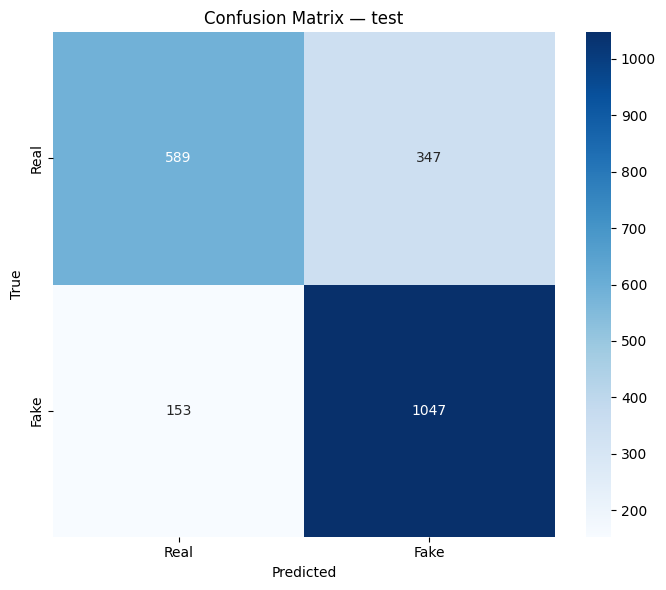

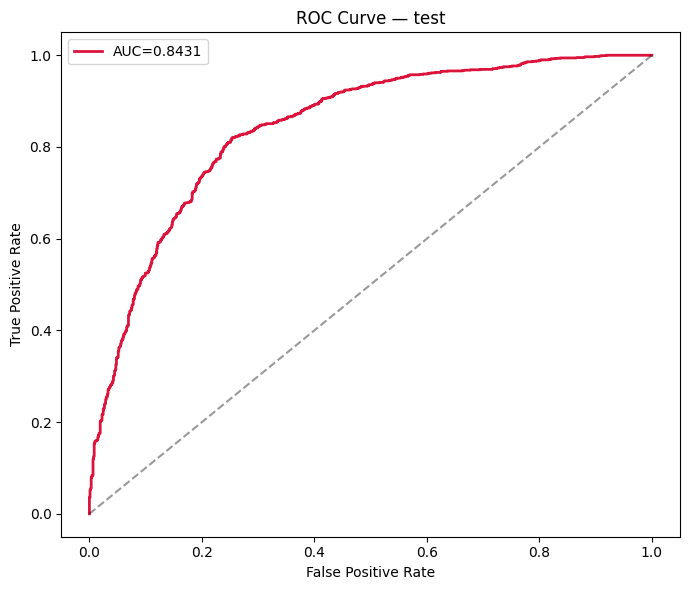

In [ ]:
from src.eval.metrics import run_inference, full_evaluation

probs, labels = run_inference(model, loader_test, device, cfg)

test_results = full_evaluation(
    probs       = probs,
    labels      = labels,
    split_name  = "test",
    out_dir     = Path("results"),
    num_classes = cfg["data"]["num_classes"],
)

Cell 6 — ASRR (Novel Metric)

/content/ghostshot/src/eval/attack_eval.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg["training"]["amp"]):



── Attack Success Rate Reduction (ASRR) ──────────────
  Total probes         : 24
  Fooled API (before)  : 4 (16.7%)
  Caught by GhostShot  : 1
  Still fooling (after): 3 (12.5%)

  ★ ASRR = 25.0%  (higher is better)
──────────────────────────────────────────────────────


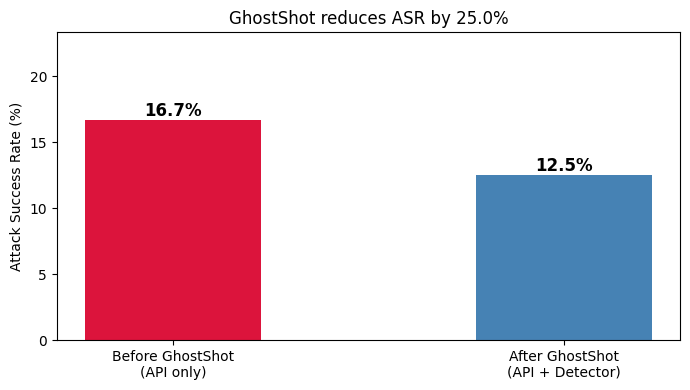

In [ ]:
from src.eval.attack_eval import compute_asrr

asrr_results = compute_asrr(
    model           = model,
    attack_log_path = Path("data/attack_samples/attack_log.csv"),
    device          = device,
    cfg             = cfg,
)

Cell 7 — GradCAM Visualization

✅ Selected 4 images for GradCAM


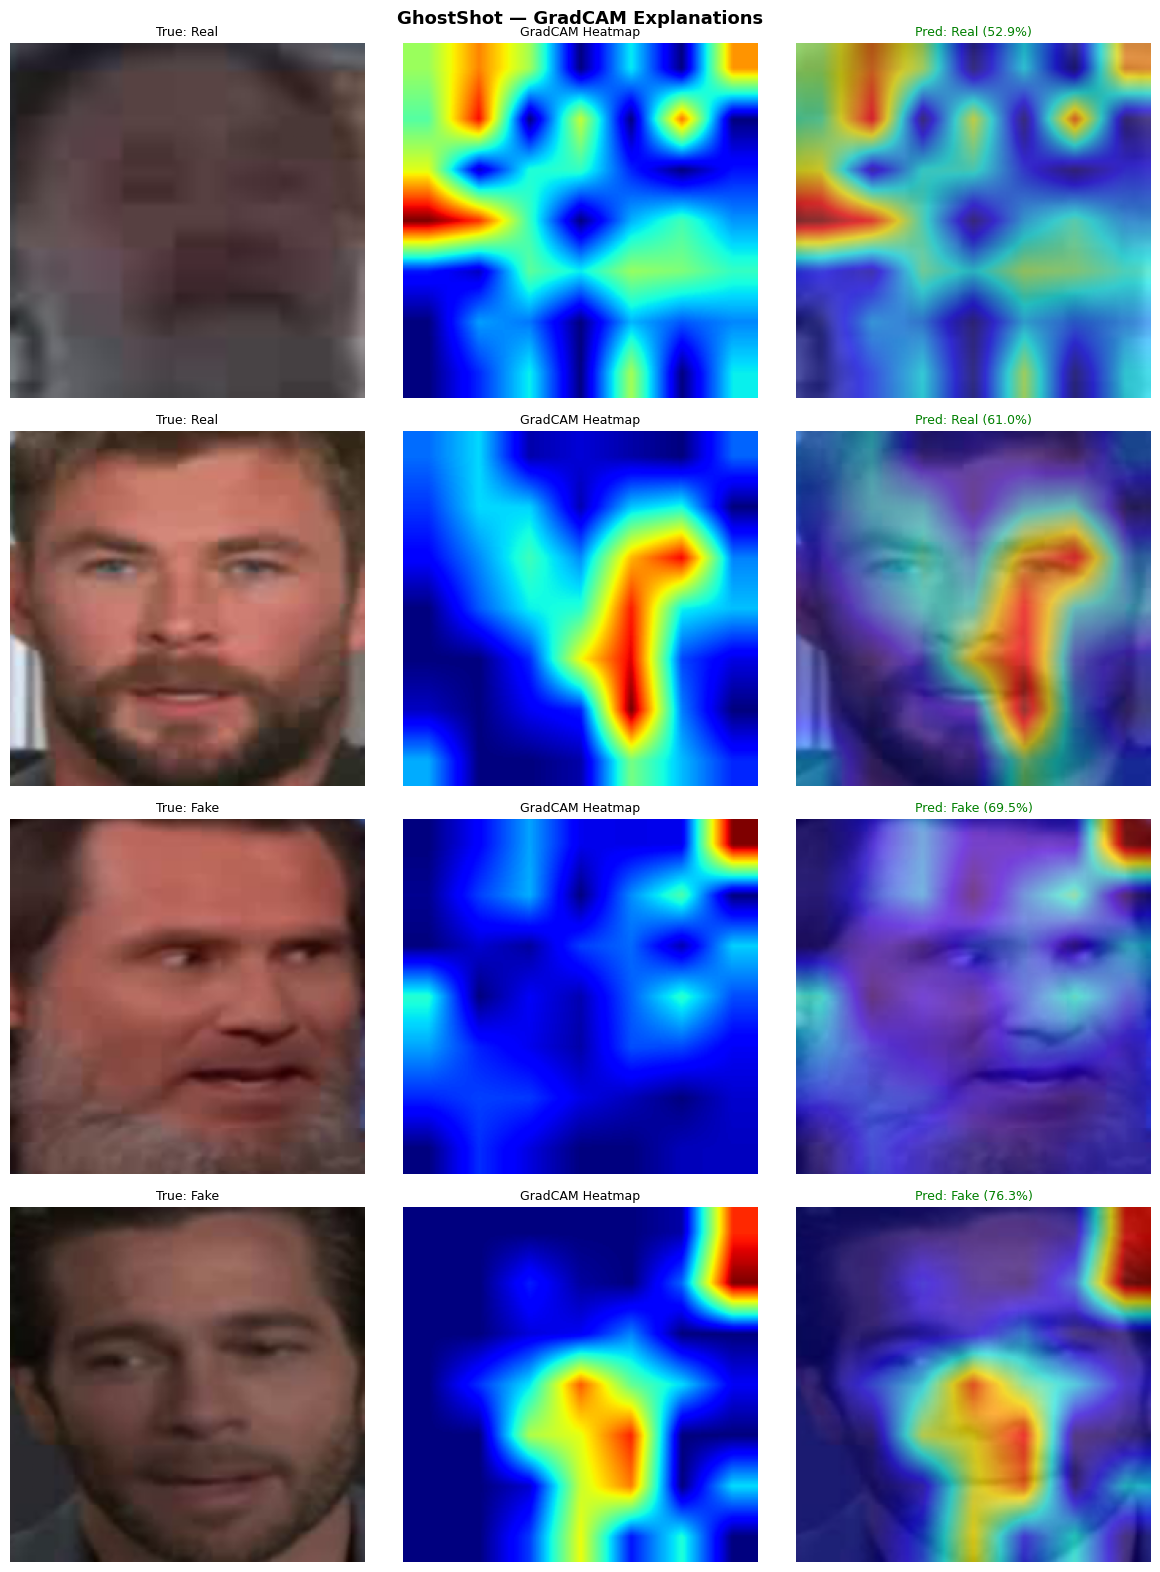

✅ GradCAM saved: results/figures/gradcam/gradcam_grid.png


In [ ]:
from src.eval.gradcam import run_gradcam
import pandas as pd
import random
from pathlib import Path

random.seed(42)

# Get sample images
test_csv  = pd.read_csv("data/processed/splits/test_small.csv"
                         if Path("data/processed/splits/test_small.csv").exists()
                         else "data/processed/splits/test.csv")

real_dirs = test_csv[test_csv["label"]==0]["crop_dir"].tolist()
fake_dirs = test_csv[test_csv["label"]==1]["crop_dir"].tolist()

def first_png(d):
    p = Path(d)
    if p.is_dir():
        pngs = list(p.glob("*.png"))
        return str(pngs[0]) if pngs else None
    return str(p) if p.exists() else None

# Pick 2 real and 2 fake samples
img_paths = []
labels    = []

for d in random.sample(real_dirs, 2):
    p = first_png(d)
    if p:
        img_paths.append(p)
        labels.append(0)

for d in random.sample(fake_dirs, 2):
    p = first_png(d)
    if p:
        img_paths.append(p)
        labels.append(1)

print(f"✅ Selected {len(img_paths)} images for GradCAM")

run_gradcam(
    model       = model,
    img_paths   = img_paths,
    true_labels = labels,
    device      = device,
    out_dir     = Path("results/figures/gradcam"),
)

In [ ]:
from google.colab import files
import os

figures = [
    "results/figures/confusion_matrix_test.png",
    "results/figures/roc_curves_test.png",
    "results/figures/asrr.png",
    "results/figures/gradcam/gradcam_grid.png",
]

for fig in figures:
    if os.path.exists(fig):
        files.download(fig)
        print(f"✅ Downloaded: {fig.split('/')[-1]}")
    else:
        print(f"❌ Not found: {fig}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: confusion_matrix_test.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: asrr.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: gradcam_grid.png


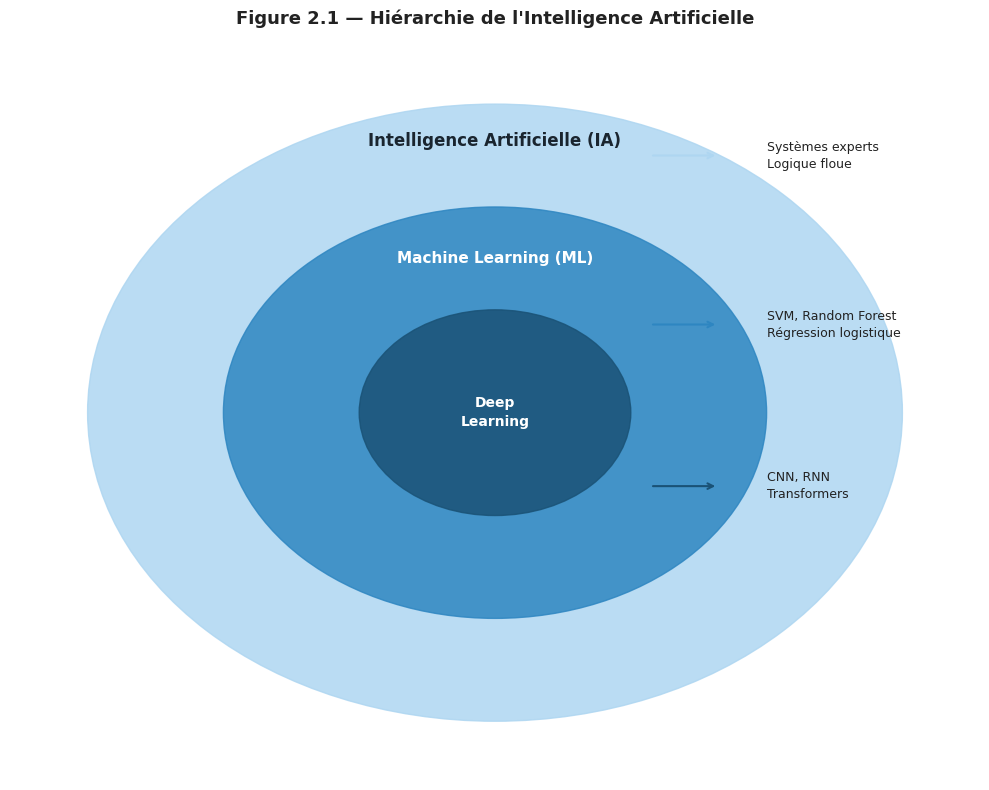

✅ Figure 2.1 sauvegardée : results/figures/fig2_1_ia_ml_dl.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs("results/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Cercles imbriqués : IA > ML > DL
circles = [
    (5, 5, 4.2, "#AED6F1", "Intelligence Artificielle (IA)", 1.2),
    (5, 5, 2.8, "#2E86C1", "Machine Learning (ML)",          2.2),
    (5, 5, 1.4, "#1A5276", "Deep\nLearning",                 4.8),
]

for (cx, cy, r, color, label, fs_y) in circles:
    circle = plt.Circle((cx, cy), r, color=color, alpha=0.85, zorder=circles.index((cx,cy,r,color,label,fs_y))+1)
    ax.add_patch(circle)

# Labels
ax.text(5, 8.7,  "Intelligence Artificielle (IA)",
        ha="center", va="center", fontsize=12, fontweight="bold", color="#1A252F")
ax.text(5, 7.1,  "Machine Learning (ML)",
        ha="center", va="center", fontsize=11, fontweight="bold", color="white")
ax.text(5, 5.0,  "Deep\nLearning",
        ha="center", va="center", fontsize=10, fontweight="bold", color="white",
        linespacing=1.5)

# Exemples à droite
examples = [
    (7.8, 8.5, "#AED6F1", "Systèmes experts\nLogique floue"),
    (7.8, 6.2, "#2E86C1", "SVM, Random Forest\nRégression logistique"),
    (7.8, 4.0, "#1A5276", "CNN, RNN\nTransformers"),
]
for (ex, ey, color, txt) in examples:
    ax.annotate("", xy=(ex - 0.5, ey), xytext=(ex - 1.2, ey),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
    ax.text(ex, ey, txt, ha="left", va="center", fontsize=9,
            color="#222222", linespacing=1.4)

ax.set_title("Figure 2.1 — Hiérarchie de l'Intelligence Artificielle",
             fontsize=13, fontweight="bold", pad=15, color="#222222")

plt.tight_layout()
plt.savefig("results/figures/fig2_1_ia_ml_dl.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 2.1 sauvegardée : results/figures/fig2_1_ia_ml_dl.png")

/tmp/ipykernel_2396/533802353.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), 0.35, color=color, zorder=3, linewidth=2,


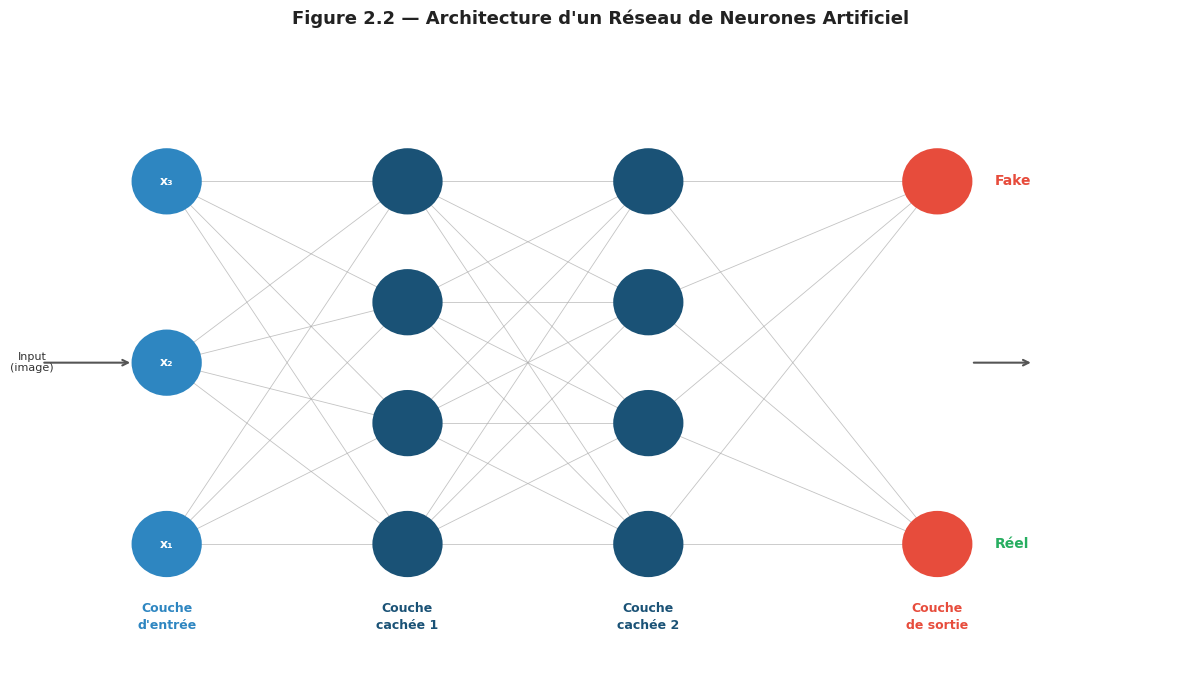

✅ Figure 2.2 sauvegardée : results/figures/fig2_2_neural_network.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

os.makedirs("results/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")

# Couches : [nb neurones, label, couleur, x]
layers = [
    (3, "Couche\nd'entrée",  "#2E86C1", 1.5),
    (4, "Couche\ncachée 1", "#1A5276", 4.0),
    (4, "Couche\ncachée 2", "#1A5276", 6.5),
    (2, "Couche\nde sortie", "#E74C3C", 9.5),
]

neuron_positions = []

for (n, label, color, x) in layers:
    positions = []
    ys = np.linspace(1.5, 5.5, n)
    for y in ys:
        circle = plt.Circle((x, y), 0.35, color=color, zorder=3, linewidth=2,
                             edgecolor="white")
        ax.add_patch(circle)
        positions.append((x, y))
    neuron_positions.append(positions)

    # Label sous la couche
    ax.text(x, 0.7, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color=color, linespacing=1.4)

# Connexions entre couches
for i in range(len(neuron_positions) - 1):
    for (x1, y1) in neuron_positions[i]:
        for (x2, y2) in neuron_positions[i+1]:
            ax.plot([x1, x2], [y1, y2], color="#AAAAAA", linewidth=0.6,
                    zorder=1, alpha=0.7)

# Labels dans les neurones d'entrée
inputs = ["x₁", "x₂", "x₃"]
for (x, y), lbl in zip(neuron_positions[0], inputs):
    ax.text(x, y, lbl, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white", zorder=4)

# Labels dans les neurones de sortie
outputs = ["Réel", "Fake"]
colors_out = ["#27AE60", "#E74C3C"]
for (x, y), lbl, c in zip(neuron_positions[-1], outputs, colors_out):
    ax.text(x + 0.6, y, lbl, ha="left", va="center",
            fontsize=10, fontweight="bold", color=c, zorder=4)

# Flèches entrée et sortie
ax.annotate("", xy=(1.15, 3.5), xytext=(0.2, 3.5),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.5))
ax.text(0.1, 3.5, "Input\n(image)", ha="center", va="center",
        fontsize=8, color="#333")

ax.annotate("", xy=(10.5, 3.5), xytext=(9.85, 3.5),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.5))

# Titre
ax.set_title("Figure 2.2 — Architecture d'un Réseau de Neurones Artificiel",
             fontsize=13, fontweight="bold", pad=15, color="#222222")

plt.tight_layout()
plt.savefig("results/figures/fig2_2_neural_network.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 2.2 sauvegardée : results/figures/fig2_2_neural_network.png")

/tmp/ipykernel_2396/4219389521.py:90: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/4219389521.py:90: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/4219389521.py:90: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/4219389521.py:90: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/4219389521.py:90: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/4219389521.py:91: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("results/figures/fig2_3_cnn_pipeline.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_2396/4219389521.py:91: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing

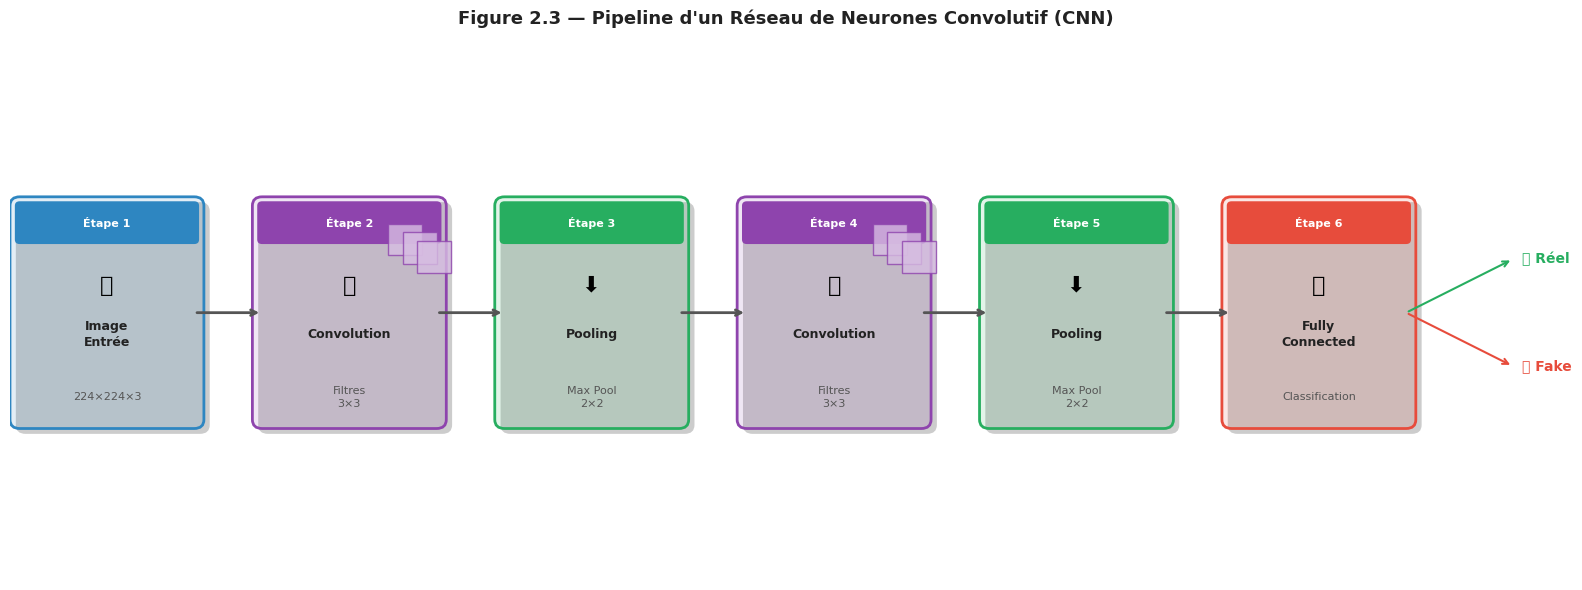

✅ Figure 2.3 sauvegardée : results/figures/fig2_3_cnn_pipeline.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
import os

os.makedirs("results/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 6))
ax.set_xlim(0, 16)
ax.set_ylim(0, 6)
ax.axis("off")

# Blocs du pipeline
blocks = [
    (1.0,  "🖼️",  "Image\nEntrée",        "224×224×3",  "#2E86C1"),
    (3.5,  "🔲",  "Convolution",          "Filtres\n3×3", "#8E44AD"),
    (6.0,  "⬇️",  "Pooling",              "Max Pool\n2×2","#27AE60"),
    (8.5,  "🔲",  "Convolution",          "Filtres\n3×3", "#8E44AD"),
    (11.0, "⬇️",  "Pooling",              "Max Pool\n2×2","#27AE60"),
    (13.5, "🧠",  "Fully\nConnected",     "Classification","#E74C3C"),
]

box_w, box_h = 1.8, 2.4
cy = 3.0

for (x, icon, label, sublabel, color) in blocks:
    # Shadow
    shadow = FancyBboxPatch((x - box_w/2 + 0.06, cy - box_h/2 - 0.06),
                             box_w, box_h, boxstyle="round,pad=0.1",
                             linewidth=0, facecolor="#cccccc", zorder=1)
    ax.add_patch(shadow)

    # Box
    box = FancyBboxPatch((x - box_w/2, cy - box_h/2),
                          box_w, box_h, boxstyle="round,pad=0.1",
                          linewidth=2, edgecolor=color,
                          facecolor=color + "22", zorder=2)
    ax.add_patch(box)

    # Top bar
    bar = FancyBboxPatch((x - box_w/2, cy + box_h/2 - 0.38),
                          box_w, 0.38, boxstyle="round,pad=0.05",
                          linewidth=0, facecolor=color, zorder=3)
    ax.add_patch(bar)

    # Icon
    ax.text(x, cy + 0.3, icon, ha="center", va="center", fontsize=16, zorder=4)

    # Label
    ax.text(x, cy - 0.25, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color="#222", zorder=4, linespacing=1.3)

    # Sublabel
    ax.text(x, cy - 0.95, sublabel, ha="center", va="center",
            fontsize=8, color="#555", zorder=4, linespacing=1.3)

    # Top bar text
    idx = blocks.index((x, icon, label, sublabel, color)) + 1
    ax.text(x, cy + box_h/2 - 0.19, f"Étape {idx}",
            ha="center", va="center", fontsize=8,
            fontweight="bold", color="white", zorder=4)

# Flèches entre blocs
arrow_xs = [(b[0] + box_w/2, blocks[i+1][0] - box_w/2)
            for i, b in enumerate(blocks[:-1])]
for (x1, x2) in arrow_xs:
    ax.annotate("", xy=(x2, cy), xytext=(x1, cy),
                arrowprops=dict(arrowstyle="->", color="#555", lw=2.0), zorder=5)

# Sorties finales
for y, lbl, c in [(3.6, "✅ Réel", "#27AE60"), (2.4, "❌ Fake", "#E74C3C")]:
    ax.text(15.6, y, lbl, ha="left", va="center",
            fontsize=10, fontweight="bold", color=c)
    ax.annotate("", xy=(15.5, y), xytext=(14.4, cy),
                arrowprops=dict(arrowstyle="->", color=c, lw=1.5), zorder=5)

# Feature maps illustration
for i, x in enumerate([3.5, 8.5]):
    for dx, dy in [(-0.15, 0.1), (0, 0), (0.15, -0.1)]:
        rect = plt.Rectangle((x + 0.55 + dx, cy + 0.55 + dy),
                               0.35, 0.35, linewidth=1,
                               edgecolor="#8E44AD", facecolor="#D7BDE2",
                               zorder=6, alpha=0.8)
        ax.add_patch(rect)

ax.set_title("Figure 2.3 — Pipeline d'un Réseau de Neurones Convolutif (CNN)",
             fontsize=13, fontweight="bold", pad=15, color="#222222")

plt.tight_layout()
plt.savefig("results/figures/fig2_3_cnn_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 2.3 sauvegardée : results/figures/fig2_3_cnn_pipeline.png")

/tmp/ipykernel_2396/1270312641.py:89: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/1270312641.py:89: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/1270312641.py:89: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/1270312641.py:89: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/1270312641.py:89: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/1270312641.py:89: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/1270312641.py:90: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.savefig("results/figu

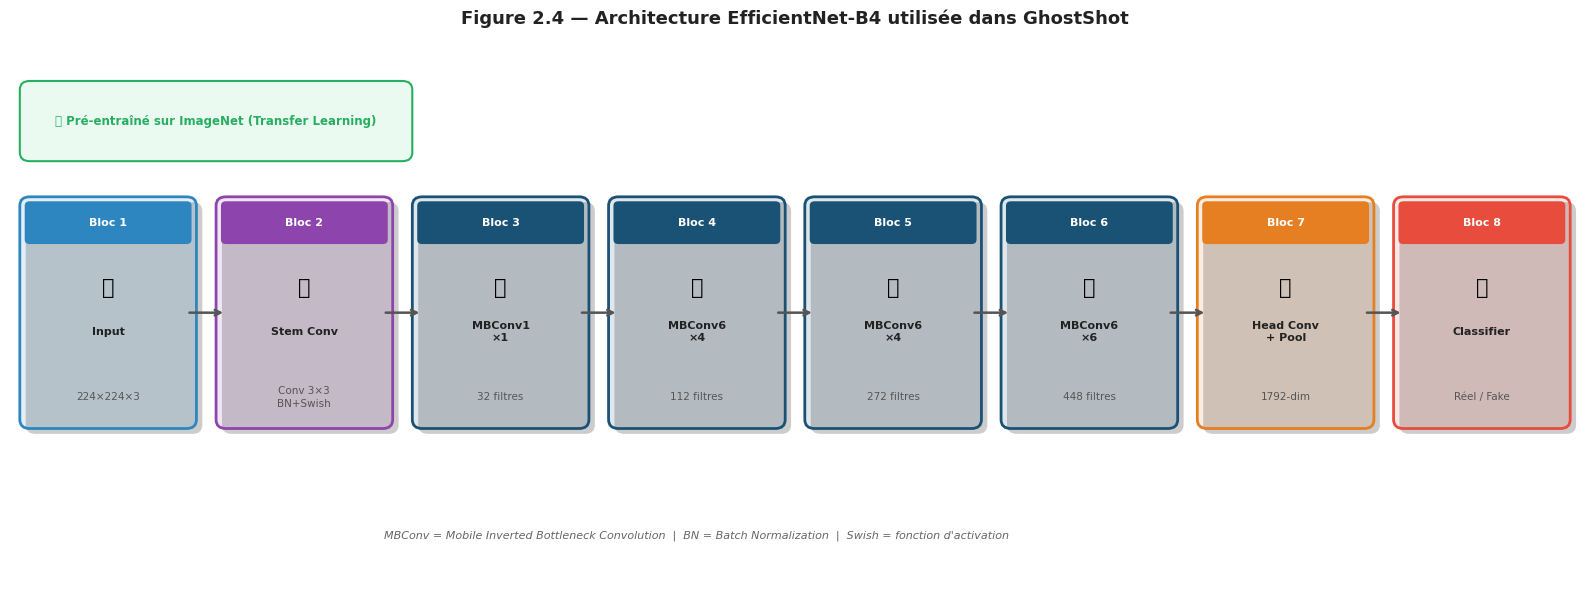

✅ Figure 2.4 sauvegardée : results/figures/fig2_4_efficientnet.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import os

os.makedirs("results/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 6))
ax.set_xlim(0, 16)
ax.set_ylim(0, 6)
ax.axis("off")

# Blocs EfficientNet-B4
blocks = [
    (1.0,  "🖼️",  "Input",           "224×224×3",     "#2E86C1", "1"),
    (3.0,  "🔲",  "Stem Conv",       "Conv 3×3\nBN+Swish", "#8E44AD", "2"),
    (5.0,  "📦",  "MBConv1\n×1",     "32 filtres",    "#1A5276", "3"),
    (7.0,  "📦",  "MBConv6\n×4",     "112 filtres",   "#1A5276", "4"),
    (9.0,  "📦",  "MBConv6\n×4",     "272 filtres",   "#1A5276", "5"),
    (11.0, "📦",  "MBConv6\n×6",     "448 filtres",   "#1A5276", "6"),
    (13.0, "🌐",  "Head Conv\n+ Pool","1792-dim",      "#E67E22", "7"),
    (15.0, "🎯",  "Classifier",      "Réel / Fake",   "#E74C3C", "8"),
]

box_w, box_h = 1.6, 2.4
cy = 3.0

for (x, icon, label, sublabel, color, step) in blocks:
    # Shadow
    shadow = FancyBboxPatch((x - box_w/2 + 0.06, cy - box_h/2 - 0.06),
                             box_w, box_h, boxstyle="round,pad=0.1",
                             linewidth=0, facecolor="#cccccc", zorder=1)
    ax.add_patch(shadow)

    # Box
    box = FancyBboxPatch((x - box_w/2, cy - box_h/2),
                          box_w, box_h, boxstyle="round,pad=0.1",
                          linewidth=2, edgecolor=color,
                          facecolor=color + "22", zorder=2)
    ax.add_patch(box)

    # Top bar
    bar = FancyBboxPatch((x - box_w/2, cy + box_h/2 - 0.38),
                          box_w, 0.38, boxstyle="round,pad=0.05",
                          linewidth=0, facecolor=color, zorder=3)
    ax.add_patch(bar)

    # Step number in bar
    ax.text(x, cy + box_h/2 - 0.19, f"Bloc {step}",
            ha="center", va="center", fontsize=8,
            fontweight="bold", color="white", zorder=4)

    # Icon
    ax.text(x, cy + 0.28, icon, ha="center", va="center", fontsize=15, zorder=4)

    # Label
    ax.text(x, cy - 0.22, label, ha="center", va="center",
            fontsize=8, fontweight="bold", color="#222", zorder=4, linespacing=1.3)

    # Sublabel
    ax.text(x, cy - 0.95, sublabel, ha="center", va="center",
            fontsize=7.5, color="#555", zorder=4, linespacing=1.3)

# Arrows
for i in range(len(blocks) - 1):
    x1 = blocks[i][0] + box_w/2
    x2 = blocks[i+1][0] - box_w/2
    ax.annotate("", xy=(x2, cy), xytext=(x1, cy),
                arrowprops=dict(arrowstyle="->", color="#555", lw=1.8), zorder=5)

# MBConv zoom note
ax.text(7.0, 0.5,
        "MBConv = Mobile Inverted Bottleneck Convolution  |  BN = Batch Normalization  |  Swish = fonction d'activation",
        ha="center", va="center", fontsize=8, color="#666",
        style="italic")

# Transfer Learning badge
badge = FancyBboxPatch((0.2, 4.8), 3.8, 0.7,
                        boxstyle="round,pad=0.1",
                        linewidth=1.5, edgecolor="#27AE60",
                        facecolor="#EAFAF1", zorder=6)
ax.add_patch(badge)
ax.text(2.1, 5.15, "✅ Pré-entraîné sur ImageNet (Transfer Learning)",
        ha="center", va="center", fontsize=8.5,
        fontweight="bold", color="#27AE60", zorder=7)

ax.set_title("Figure 2.4 — Architecture EfficientNet-B4 utilisée dans GhostShot",
             fontsize=13, fontweight="bold", pad=15, color="#222222")

plt.tight_layout()
plt.savefig("results/figures/fig2_4_efficientnet.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 2.4 sauvegardée : results/figures/fig2_4_efficientnet.png")

/tmp/ipykernel_2396/652902430.py:65: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/652902430.py:66: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("results/figures/fig2_5_fft_comparison.png", dpi=150, bbox_inches="tight")


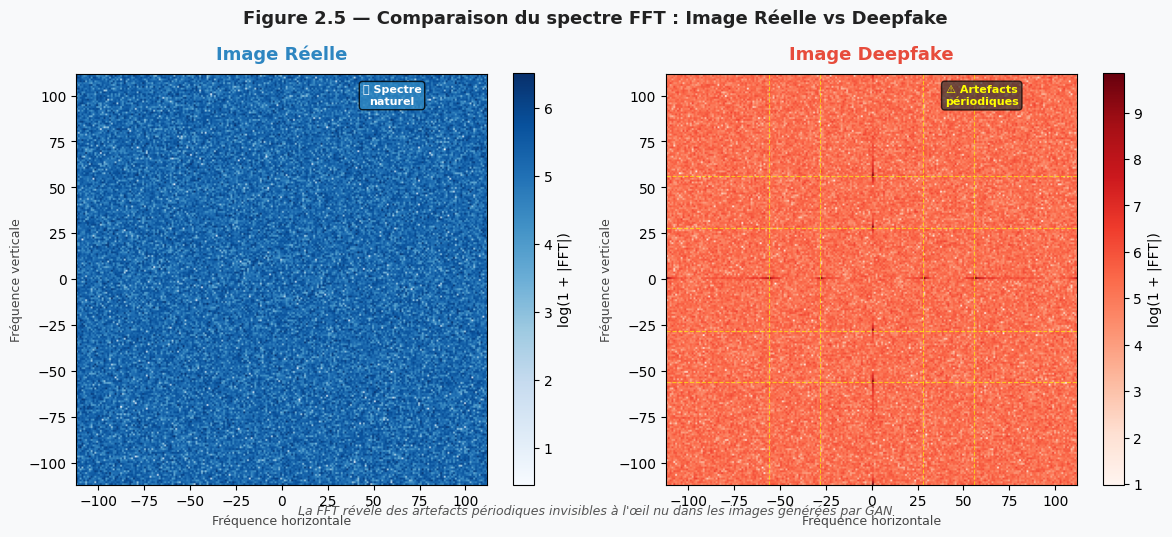

✅ Figure 2.5 sauvegardée : results/figures/fig2_5_fft_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("results/figures", exist_ok=True)

np.random.seed(42)

def make_fft_spectrum(fake=False):
    """Simule un spectre FFT d'une image réelle ou fake."""
    size = 224
    img = np.random.randn(size, size)

    if fake:
        # Artefacts fréquentiels périodiques typiques des GAN
        for freq in [28, 56, 112]:
            img += 0.6 * np.sin(2 * np.pi * freq * np.linspace(0, 1, size))[:, None]
            img += 0.6 * np.sin(2 * np.pi * freq * np.linspace(0, 1, size))[None, :]

    fft = np.fft.fft2(img)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.log1p(np.abs(fft_shift))
    return magnitude

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor("#F8F9FA")

titles  = ["Image Réelle", "Image Deepfake"]
fakes   = [False, True]
cmaps   = ["Blues", "Reds"]
colors  = ["#2E86C1", "#E74C3C"]

for i, (ax, title, fake, cmap, color) in enumerate(zip(axes, titles, fakes, cmaps, colors)):
    spectrum = make_fft_spectrum(fake=fake)
    im = ax.imshow(spectrum, cmap=cmap, origin="lower",
                   extent=[-112, 112, -112, 112])
    ax.set_title(title, fontsize=13, fontweight="bold", color=color, pad=10)
    ax.set_xlabel("Fréquence horizontale", fontsize=9, color="#444")
    ax.set_ylabel("Fréquence verticale", fontsize=9, color="#444")
    plt.colorbar(im, ax=ax, label="log(1 + |FFT|)")

    if fake:
        # Annoter les artefacts périodiques
        for freq in [28, -28, 56, -56]:
            ax.axhline(freq, color="yellow", linewidth=0.8, alpha=0.6, linestyle="--")
            ax.axvline(freq, color="yellow", linewidth=0.8, alpha=0.6, linestyle="--")
        ax.text(60, 100, "⚠️ Artefacts\npériodiques",
                ha="center", va="center", fontsize=8,
                color="yellow", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#333", alpha=0.7))
    else:
        ax.text(60, 100, "✅ Spectre\nnaturel",
                ha="center", va="center", fontsize=8,
                color="white", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#2E86C1", alpha=0.8))

# Note explicative
fig.text(0.5, 0.01,
         "La FFT révèle des artefacts périodiques invisibles à l'œil nu dans les images générées par GAN",
         ha="center", fontsize=9, style="italic", color="#555")

fig.suptitle("Figure 2.5 — Comparaison du spectre FFT : Image Réelle vs Deepfake",
             fontsize=13, fontweight="bold", color="#222", y=1.02)

plt.tight_layout()
plt.savefig("results/figures/fig2_5_fft_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 2.5 sauvegardée : results/figures/fig2_5_fft_comparison.png")

/tmp/ipykernel_2396/2936839072.py:86: UserWarning: Glyph 127922 (\N{GAME DIE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/2936839072.py:86: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/2936839072.py:86: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/2936839072.py:86: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/2936839072.py:86: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/2936839072.py:86: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2396/2936839072.py:86: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s)

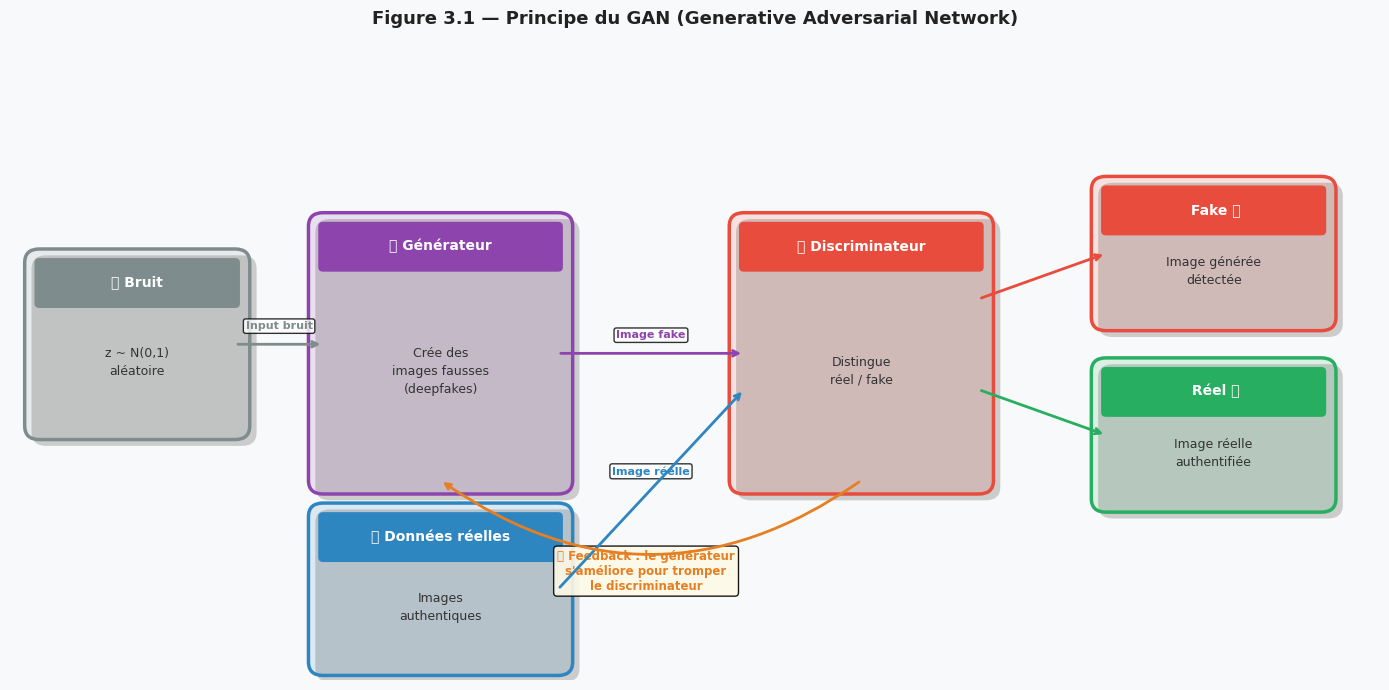

✅ Figure 3.1 sauvegardée : results/figures/fig3_1_gan.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import os

os.makedirs("results/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")
fig.patch.set_facecolor("#F8F9FA")

def draw_box(ax, x, y, w, h, color, label, sublabel=None, icon=""):
    shadow = FancyBboxPatch((x + 0.07, y - 0.07), w, h,
                             boxstyle="round,pad=0.15",
                             linewidth=0, facecolor="#cccccc", zorder=1)
    ax.add_patch(shadow)
    box = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.15",
                          linewidth=2.5, edgecolor=color,
                          facecolor=color + "22", zorder=2)
    ax.add_patch(box)
    bar = FancyBboxPatch((x, y + h - 0.45), w, 0.45,
                          boxstyle="round,pad=0.05",
                          linewidth=0, facecolor=color, zorder=3)
    ax.add_patch(bar)
    ax.text(x + w/2, y + h - 0.22, icon + " " + label,
            ha="center", va="center", fontsize=10,
            fontweight="bold", color="white", zorder=4)
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.2, sublabel,
                ha="center", va="center", fontsize=9,
                color="#333", zorder=4, linespacing=1.5)

# Bruit aléatoire (input)
draw_box(ax, 0.3, 2.8, 2.0, 1.8, "#7F8C8D", "Bruit", "z ~ N(0,1)\naléatoire", "🎲")

# Générateur
draw_box(ax, 3.2, 2.2, 2.4, 2.8, "#8E44AD", "Générateur", "Crée des\nimages fausses\n(deepfakes)", "🎨")

# Images réelles
draw_box(ax, 3.2, 0.2, 2.4, 1.6, "#2E86C1", "Données réelles", "Images\nauthentiques", "🖼️")

# Discriminateur
draw_box(ax, 7.5, 2.2, 2.4, 2.8, "#E74C3C", "Discriminateur", "Distingue\nréel / fake", "🔍")

# Sorties
draw_box(ax, 11.2, 4.0, 2.2, 1.4, "#E74C3C", "Fake ❌", "Image générée\ndétectée", "")
draw_box(ax, 11.2, 2.0, 2.2, 1.4, "#27AE60", "Réel ✅", "Image réelle\nauthentifiée", "")

# Flèches
arrows = [
    # bruit → générateur
    ((2.3, 3.7), (3.2, 3.7), "#7F8C8D", "Input bruit"),
    # générateur → discriminateur (fake)
    ((5.6, 3.6), (7.5, 3.6), "#8E44AD", "Image fake"),
    # réelles → discriminateur
    ((5.6, 1.0), (7.5, 3.2), "#2E86C1", "Image réelle"),
    # discriminateur → fake
    ((9.9, 4.2), (11.2, 4.7), "#E74C3C", ""),
    # discriminateur → réel
    ((9.9, 3.2), (11.2, 2.7), "#27AE60", ""),
]

for (start, end, color, label) in arrows:
    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(arrowstyle="->", color=color, lw=2.0), zorder=5)
    if label:
        mx, my = (start[0] + end[0])/2, (start[1] + end[1])/2 + 0.2
        ax.text(mx, my, label, ha="center", va="center",
                fontsize=8, color=color, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

# Flèche feedback (discriminateur → générateur)
ax.annotate("", xy=(4.4, 2.2), xytext=(8.7, 2.2),
            arrowprops=dict(arrowstyle="->", color="#E67E22", lw=2.0,
                            connectionstyle="arc3,rad=-0.35"), zorder=5)
ax.text(6.5, 1.2, "🔄 Feedback : le générateur\ns'améliore pour tromper\nle discriminateur",
        ha="center", va="center", fontsize=8.5, color="#E67E22",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#FEF9E7", alpha=0.9))

ax.set_title("Figure 3.1 — Principe du GAN (Generative Adversarial Network)",
             fontsize=13, fontweight="bold", color="#222", pad=15)

plt.tight_layout()
plt.savefig("results/figures/fig3_1_gan.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 3.1 sauvegardée : results/figures/fig3_1_gan.png")

/tmp/ipykernel_3832/2876999635.py:91: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3832/2876999635.py:91: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3832/2876999635.py:91: UserWarning: Glyph 128452 (\N{FILE CABINET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3832/2876999635.py:91: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3832/2876999635.py:91: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3832/2876999635.py:91: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3832/2876999635.py:91: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3832/2876999635.py:9

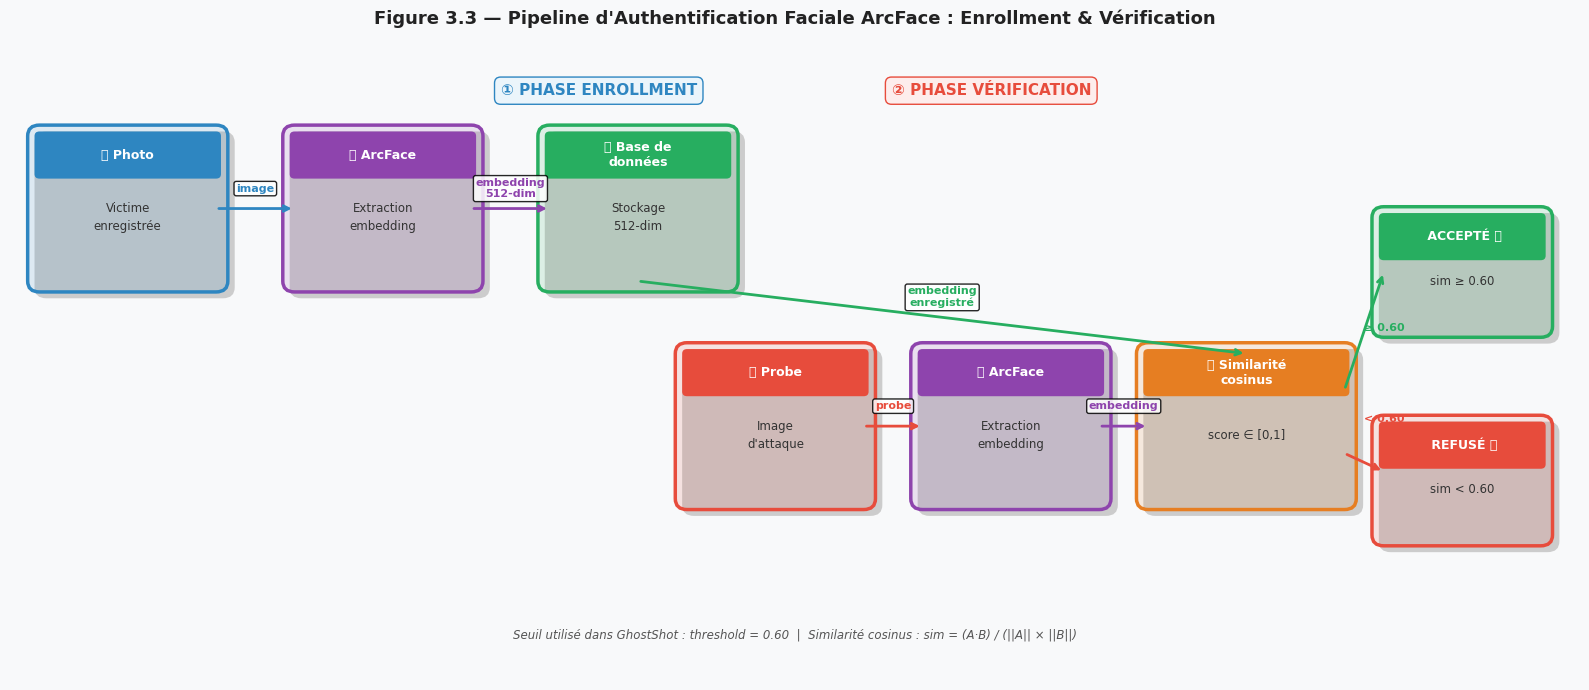

✅ Figure 3.3 sauvegardée : results/figures/fig3_3_face_auth.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import os

os.makedirs("results/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(0, 16)
ax.set_ylim(0, 7)
ax.axis("off")
fig.patch.set_facecolor("#F8F9FA")

def draw_box(ax, x, cy, w, h, color, title, subtitle=None, icon=""):
    shadow = FancyBboxPatch((x - w/2 + 0.07, cy - h/2 - 0.07), w, h,
                             boxstyle="round,pad=0.12",
                             linewidth=0, facecolor="#cccccc", zorder=1)
    ax.add_patch(shadow)
    box = FancyBboxPatch((x - w/2, cy - h/2), w, h,
                          boxstyle="round,pad=0.12",
                          linewidth=2.5, edgecolor=color,
                          facecolor=color + "22", zorder=2)
    ax.add_patch(box)
    bar = FancyBboxPatch((x - w/2, cy + h/2 - 0.42), w, 0.42,
                          boxstyle="round,pad=0.05",
                          linewidth=0, facecolor=color, zorder=3)
    ax.add_patch(bar)
    ax.text(x, cy + h/2 - 0.21, icon + " " + title,
            ha="center", va="center", fontsize=9,
            fontweight="bold", color="white", zorder=4)
    if subtitle:
        ax.text(x, cy - 0.1, subtitle,
                ha="center", va="center", fontsize=8.5,
                color="#333", zorder=4, linespacing=1.5)

def arrow(ax, x1, y1, x2, y2, color, label=""):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color=color, lw=2.0), zorder=5)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2 + 0.22
        ax.text(mx, my, label, ha="center", va="center", fontsize=8,
                color=color, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85))

# ── ENROLLMENT (haut) ───────────────────────────────────
ax.text(6.0, 6.5, "① PHASE ENROLLMENT",
        ha="center", va="center", fontsize=11,
        fontweight="bold", color="#2E86C1",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#EBF5FB", edgecolor="#2E86C1"))

draw_box(ax, 1.2, 5.2, 1.8, 1.6, "#2E86C1", "Photo",      "Victime\nenregistrée",   "📷")
draw_box(ax, 3.8, 5.2, 1.8, 1.6, "#8E44AD", "ArcFace",    "Extraction\nembedding",   "🧠")
draw_box(ax, 6.4, 5.2, 1.8, 1.6, "#27AE60", "Base de\ndonnées", "Stockage\n512-dim","🗄️")

arrow(ax, 2.1, 5.2, 2.9, 5.2, "#2E86C1", "image")
arrow(ax, 4.7, 5.2, 5.5, 5.2, "#8E44AD", "embedding\n512-dim")

# ── VERIFICATION (bas) ──────────────────────────────────
ax.text(10.0, 6.5, "② PHASE VÉRIFICATION",
        ha="center", va="center", fontsize=11,
        fontweight="bold", color="#E74C3C",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDEDEC", edgecolor="#E74C3C"))

draw_box(ax, 7.8,  2.8, 1.8, 1.6, "#E74C3C", "Probe",      "Image\nd'attaque",      "🎭")
draw_box(ax, 10.2, 2.8, 1.8, 1.6, "#8E44AD", "ArcFace",    "Extraction\nembedding",  "🧠")
draw_box(ax, 12.6, 2.8, 2.0, 1.6, "#E67E22", "Similarité\ncosinus", "score ∈ [0,1]","📐")

arrow(ax, 8.7,  2.8, 9.3,  2.8, "#E74C3C", "probe")
arrow(ax, 11.1, 2.8, 11.6, 2.8, "#8E44AD", "embedding")

# Connexion base de données → similarité
arrow(ax, 6.4, 4.4, 12.6, 3.6, "#27AE60", "embedding\nenregistré")

# Décision
draw_box(ax, 14.8, 4.5, 1.6, 1.2, "#27AE60", "ACCEPTÉ ✅", "sim ≥ 0.60", "")
draw_box(ax, 14.8, 2.2, 1.6, 1.2, "#E74C3C", "REFUSÉ ❌",  "sim < 0.60", "")

arrow(ax, 13.6, 3.2, 14.0, 4.5, "#27AE60", "")
arrow(ax, 13.6, 2.5, 14.0, 2.3, "#E74C3C", "")

ax.text(13.8, 3.85, "≥ 0.60", fontsize=8, color="#27AE60", fontweight="bold")
ax.text(13.8, 2.85, "< 0.60", fontsize=8, color="#E74C3C", fontweight="bold")

# Seuil note
ax.text(8.0, 0.5,
        "Seuil utilisé dans GhostShot : threshold = 0.60  |  Similarité cosinus : sim = (A·B) / (||A|| × ||B||)",
        ha="center", va="center", fontsize=8.5, color="#555", style="italic")

ax.set_title("Figure 3.3 — Pipeline d'Authentification Faciale ArcFace : Enrollment & Vérification",
             fontsize=13, fontweight="bold", color="#222", pad=15)

plt.tight_layout()
plt.savefig("results/figures/fig3_3_face_auth.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 3.3 sauvegardée : results/figures/fig3_3_face_auth.png")

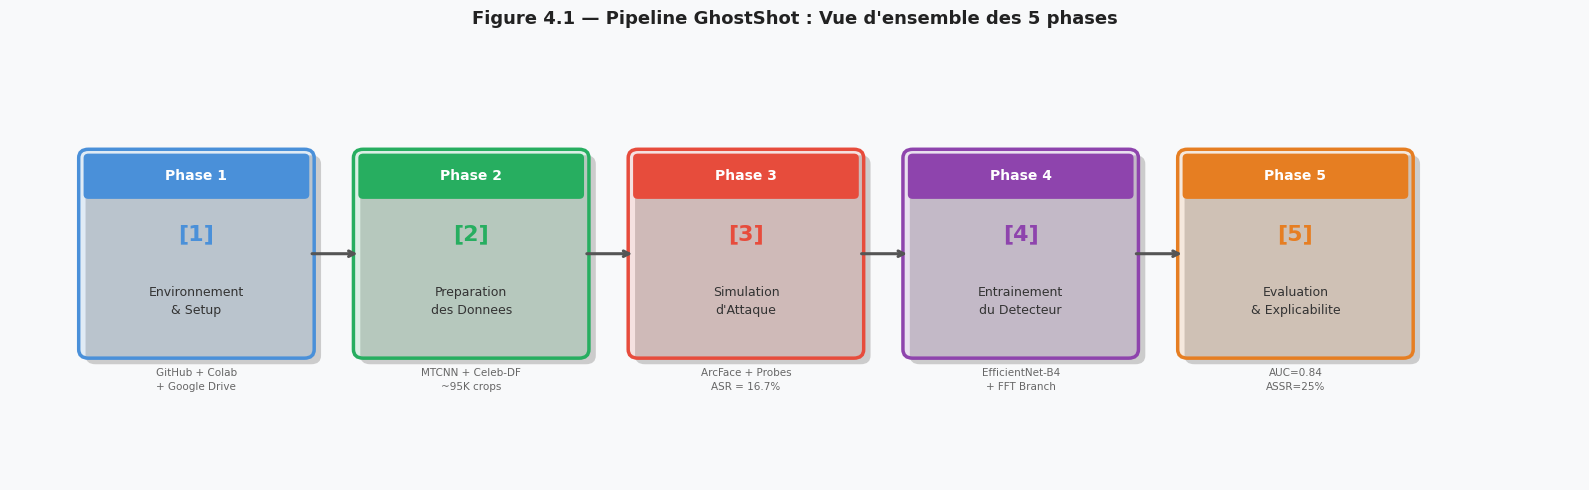

✅ Figure 4.1 sauvegardee : results/figures/fig4_1_pipeline.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import os

os.makedirs("results/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 5))
ax.set_xlim(0, 16)
ax.set_ylim(0, 5)
ax.axis("off")
fig.patch.set_facecolor("#F8F9FA")

phases = [
    ("Phase 1",  "Environnement\n& Setup",       "#4A90D9"),
    ("Phase 2",  "Preparation\ndes Donnees",      "#27AE60"),
    ("Phase 3",  "Simulation\nd'Attaque",         "#E74C3C"),
    ("Phase 4",  "Entrainement\ndu Detecteur",    "#8E44AD"),
    ("Phase 5",  "Evaluation\n& Explicabilite",   "#E67E22"),
]

icons = ["[1]", "[2]", "[3]", "[4]", "[5]"]

box_w, box_h = 2.2, 2.2
gap          = 0.6
start_x      = 0.8
cy           = 2.6

xs = [start_x + i * (box_w + gap) for i in range(5)]

for i, ((phase, desc, color), icon) in enumerate(zip(phases, icons)):
    x = xs[i]

    # Shadow
    shadow = FancyBboxPatch((x + 0.07, cy - box_h/2 - 0.07),
                             box_w, box_h,
                             boxstyle="round,pad=0.1",
                             linewidth=0, facecolor="#cccccc", zorder=1)
    ax.add_patch(shadow)

    # Main box
    box = FancyBboxPatch((x, cy - box_h/2), box_w, box_h,
                          boxstyle="round,pad=0.1",
                          linewidth=2.5, edgecolor=color,
                          facecolor=color + "22", zorder=2)
    ax.add_patch(box)

    # Top bar
    bar = FancyBboxPatch((x, cy + box_h/2 - 0.42), box_w, 0.42,
                          boxstyle="round,pad=0.05",
                          linewidth=0, facecolor=color, zorder=3)
    ax.add_patch(bar)

    # Phase label in bar
    ax.text(x + box_w/2, cy + box_h/2 - 0.21, phase,
            ha="center", va="center", fontsize=10,
            fontweight="bold", color="white", zorder=4)

    # Icon number
    ax.text(x + box_w/2, cy + 0.22, icon,
            ha="center", va="center", fontsize=16,
            fontweight="bold", color=color, zorder=4)

    # Description
    ax.text(x + box_w/2, cy - 0.55, desc,
            ha="center", va="center", fontsize=9,
            color="#333333", zorder=4, linespacing=1.5)

    # Arrow to next box
    if i < 4:
        ax_x = x + box_w + 0.05
        ax.annotate("", xy=(ax_x + gap - 0.08, cy),
                    xytext=(ax_x, cy),
                    arrowprops=dict(arrowstyle="->", color="#555555",
                                   lw=2.2), zorder=5)

# Subtitle under each phase
subtitles = [
    "GitHub + Colab\n+ Google Drive",
    "MTCNN + Celeb-DF\n~95K crops",
    "ArcFace + Probes\nASR = 16.7%",
    "EfficientNet-B4\n+ FFT Branch",
    "AUC=0.84\nASSR=25%",
]
for i, (x, sub) in enumerate(zip(xs, subtitles)):
    ax.text(x + box_w/2, cy - box_h/2 - 0.35, sub,
            ha="center", va="center", fontsize=7.5,
            color="#666", linespacing=1.4)

ax.set_title("Figure 4.1 — Pipeline GhostShot : Vue d'ensemble des 5 phases",
             fontsize=13, fontweight="bold", color="#222222", pad=15)

plt.tight_layout()
plt.savefig("results/figures/fig4_1_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 4.1 sauvegardee : results/figures/fig4_1_pipeline.png")

In [ ]:
from google.colab import files
import os

# Toutes les figures du rapport
figures = [
    # Chapitre 2 — Théorie
    "results/figures/fig2_1_ia_ml_dl.png",
    "results/figures/fig2_2_neural_network.png",
    "results/figures/fig2_3_cnn_pipeline.png",
    "results/figures/fig2_4_efficientnet.png",
    "results/figures/fig2_5_fft_comparison.png",

    # Chapitre 3 — Deepfakes & Face Auth
    "results/figures/fig3_1_gan.png",
    "results/figures/fig3_3_face_auth.png",

    # Chapitre 4 — Projet GhostShot
    "results/figures/fig4_1_pipeline.png",
    "results/figures/mtcnn_detection.png",
    "results/figures/sample_face_crops.png",
    "results/figures/dataset_distribution.png",
    "results/figures/phase3_attack_results.png",
    "results/figures/asrr.png",
    "results/figures/model_architecture.png",
    "results/figures/phase4_training_curves.png",
    "results/figures/phase4_confusion_matrix.png",
    "results/figures/phase4_roc_curve.png",
    "results/figures/confusion_matrix_test.png",
    "results/figures/roc_curves_test.png",
    "results/figures/gradcam/gradcam_grid.png",
]

print("── Téléchargement des figures ────────────────────────")
ok, missing = 0, []

for fig in figures:
    if os.path.exists(fig):
        files.download(fig)
        print(f"  ✅ {fig.split('/')[-1]}")
        ok += 1
    else:
        print(f"  ❌ Introuvable : {fig.split('/')[-1]}")
        missing.append(fig)

print(f"\n── Résumé ────────────────────────────────────────────")
print(f"  Téléchargées : {ok}/{len(figures)}")
if missing:
    print(f"  Manquantes   : {len(missing)}")
    for m in missing:
        print(f"    - {m.split('/')[-1]}")
else:
    print("  Toutes les figures sont prêtes pour le rapport !")

── Téléchargement des figures ────────────────────────


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ fig2_1_ia_ml_dl.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ roc_curves_test.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ gradcam_grid.png

── Résumé ────────────────────────────────────────────
  Téléchargées : 20/20
  Toutes les figures sont prêtes pour le rapport !
